In [315]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
import os

parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])
rul_df['unit_number'] = rul_df.index + 1 # 엔진 번호(1부터 시작) 추가

train_df

Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD001.txt


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


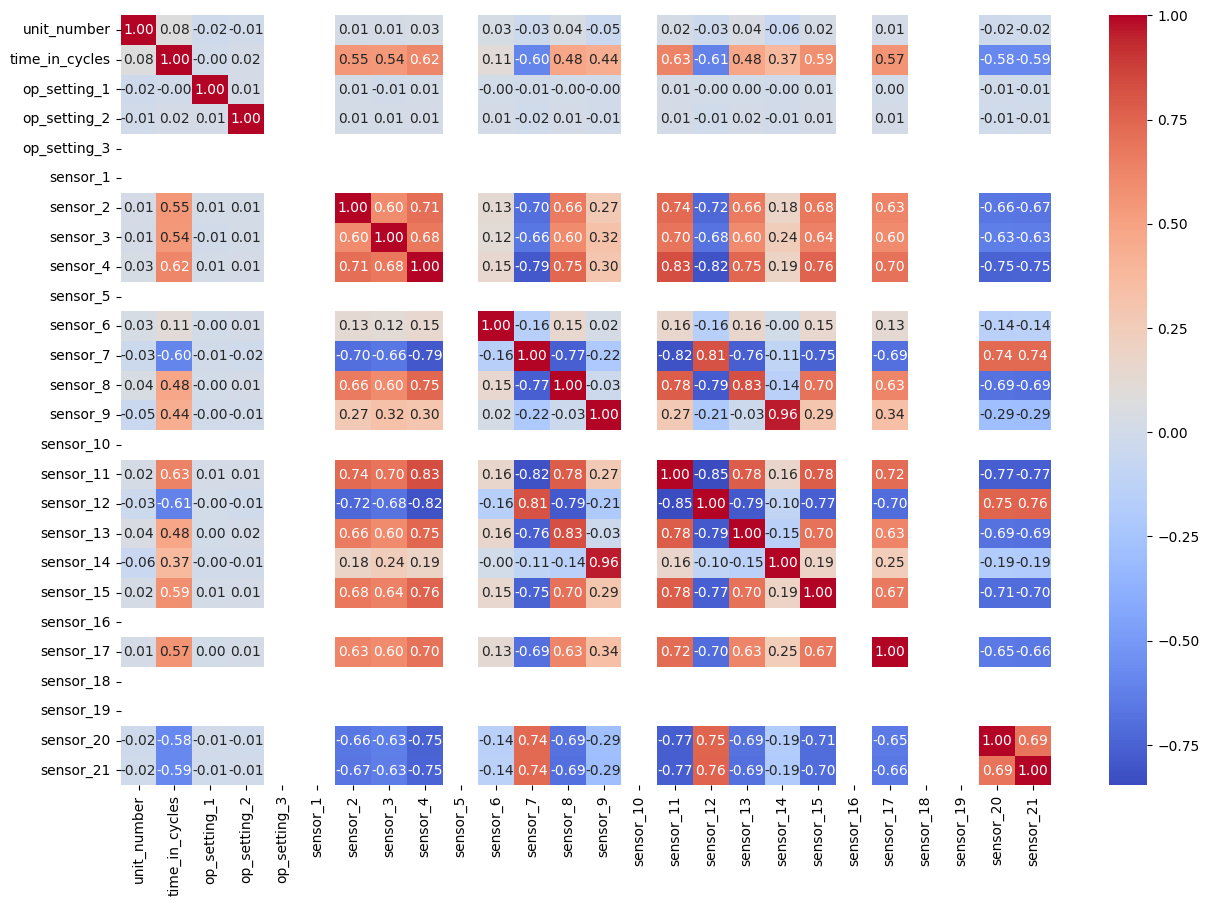

In [316]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [317]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s]
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [318]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ?
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,1.478112,1.237434,2.476863,37.917921,24763.2002,229.288891,291.767891,2456.539756,2748.307647,47.47
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,1.478112,1.238070,2.478891,37.876197,24803.0772,229.658122,292.081722,2462.774665,2754.856388,47.49
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,1.478112,1.238456,2.472157,37.911081,24694.7934,228.655494,290.949694,2449.156338,2740.106032,47.27
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,1.478112,1.238456,2.464062,37.924077,24642.3918,228.170294,290.424194,2430.327744,2720.751938,47.13
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,1.478112,1.238495,2.464078,37.893297,24689.1432,228.603178,290.907578,2452.176336,2743.083914,47.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,1.478112,1.240654,2.483302,37.717510,24971.8843,231.221151,292.684651,2486.531720,2779.216371,48.07
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,1.478112,1.240750,2.493241,37.678523,24965.4272,231.161363,292.620763,2491.343914,2783.964677,48.04
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,1.478112,1.240519,2.490535,37.683995,25007.2809,231.548897,292.922197,2508.761450,2801.683648,48.09
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,1.478112,1.240153,2.495624,37.666211,25146.8313,232.841031,294.195031,2512.101946,2806.296977,48.39


In [324]:
# 1. 제거 대상을 리스트에 추가합니다 (P50[psi] 포함)
drop_features_renamed = [
    'Alt[kft]', 'Mn[-]', 'TLA[deg]',  # 환경 변수 (op_setting_1, 2, 3)
    'T2[R]', 'P2[psi]', 'P15[psi]', 'epr[-]', 'farB[-]', # 상수 센서 (sensor_1, 5, 6, 10, 16)
    'Nf_dmd[rpm]', 'PCNfR_dmd[Pct]',  # 상수 센서 (sensor_18, 19)
    'P50[psi]' # 계산 결과물 중에서도 정보 가치가 없는 항목 (epr * P2)
]

# 2. train_df와 test_df에서 일괄 삭제
train_df.drop(columns=drop_features_renamed, inplace=True, errors='ignore')
test_df.drop(columns=drop_features_renamed, inplace=True, errors='ignore')

# 3. 확인
print(f"--- 다이어트 완료 ---")
print(f"진짜 남은 피처 개수: {len(train_df.columns) - 2}개 (unit_number, time_in_cycles 제외)")
print(f"P50[psi] 제거 확인:", 'P50[psi]' not in train_df.columns)

--- 다이어트 완료 ---
진짜 남은 피처 개수: 24개 (unit_number, time_in_cycles 제외)
P50[psi] 제거 확인: True


In [373]:
train_df.columns

Index(['unit_number', 'time_in_cycles', 'T24[R]', 'T30[R]', 'T50[R]',
       'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]',
       'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]',
       'W32[lbm/s]', 'Fan.PR[-]', 'LPC.TR[-]', 'HPC.TR[-]', 'OPR[-]',
       'Wf[pph]', 'Wa36[lbm/s]', 'W24[lbm/s]', 'W15[lbm/s]', 'W2[lbm/s]',
       'WfP3C[pph/psi]', 'RUL'],
      dtype='object')

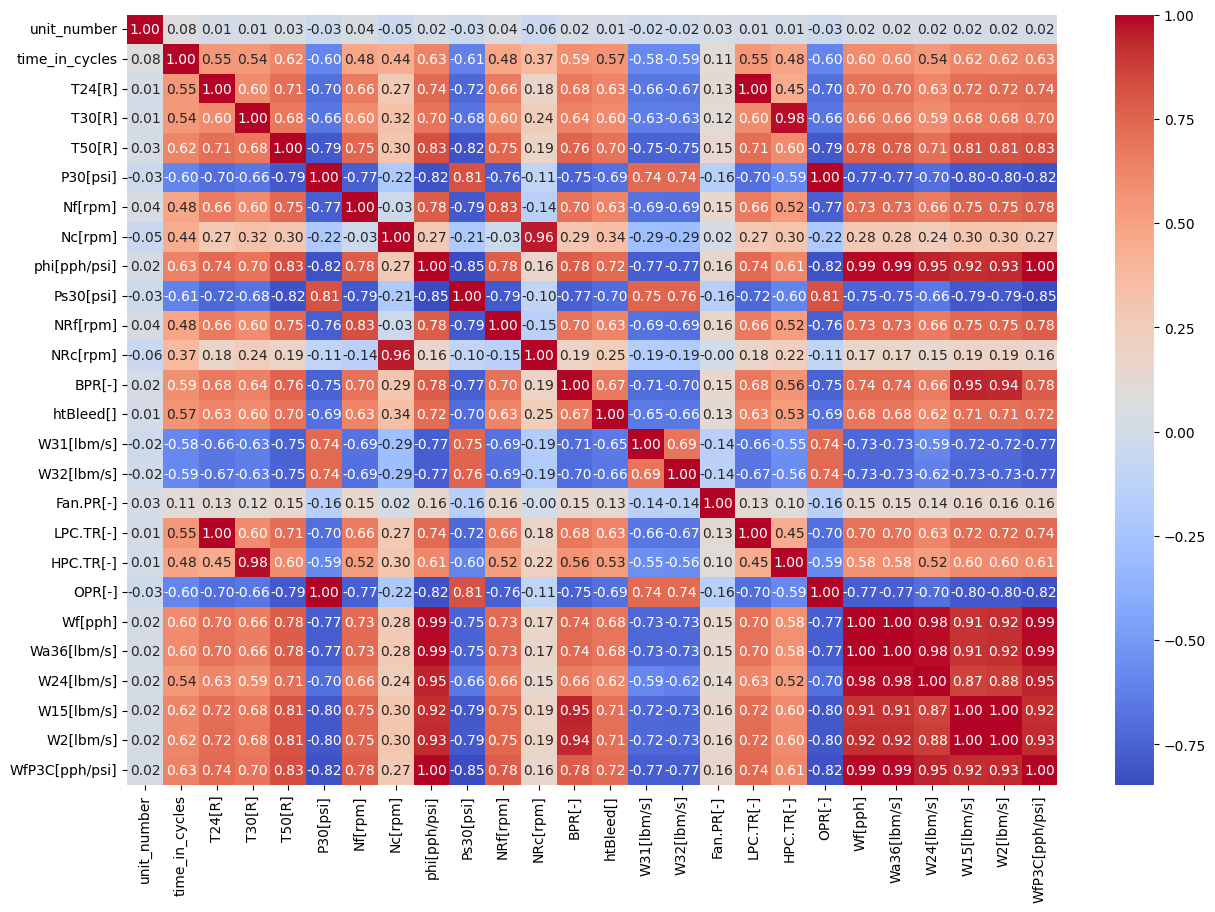

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [326]:
# 1. 테스트 데이터에서 각 엔진(unit_number)의 마지막 타임스텝(사이클)만 추출
test_last_cycle = test_df.groupby('unit_number').last().reset_index()

# 2. 추출된 데이터와 불러온 RUL 데이터(rul_df)를 unit_number를 기준으로 합침
# 이 과정에서 'test_with_rul' 변수가 생성됩니다.
test_with_rul = pd.merge(test_last_cycle, rul_df, on='unit_number')

In [328]:
# --- [추가] GroupShuffleSplit으로 엔진 단위 분할 ---
# 80% 엔진은 학습용, 20% 엔진은 검증용으로 나눕니다.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['unit_number']))

train_split = train_df.iloc[train_idx]
val_split = train_df.iloc[val_idx]

# 2. X(입력 변수)와 y(정답) 준비
X_train_raw = train_split.drop(columns=drop_cols, errors='ignore')
y_train = train_split['RUL']

X_val_raw = val_split.drop(columns=drop_cols, errors='ignore')
y_val = val_split['RUL']

# 무한대 및 결측치 처리 (함수로 만들면 더 깔끔합니다)
X_train_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train_raw.fillna(X_train_raw.median(), inplace=True)

X_val_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val_raw.fillna(X_train_raw.median(), inplace=True) # 중요: 학습 데이터의 중앙값 사용

In [329]:
# 1. 윈도우 사이즈 설정
window_size = 10

# 2. 계산할 컬럼 리스트 (X_train_raw에 있는 모든 컬럼 사용, P50 포함)
cols_to_smooth = list(X_train_raw.columns)

# 3. 학습 및 검증 데이터 가공 (train_split, val_split)
for col in cols_to_smooth:
    # 컬럼이 존재할 때만 실행하여 KeyError 방지
    if col in train_split.columns:
        train_split[f'{col}_rolling'] = train_split.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean())
    
    if col in val_split.columns:
        val_split[f'{col}_rolling'] = val_split.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean())

# 4. 테스트 데이터 가공 (중요!)
# test_with_rul이 마지막 타임스텝만 있다면 Rolling이 안 될 수 있습니다.
# 그래서 컬럼 유무를 확인하고, 없으면 에러 대신 0 등을 채워 스케일러 오류를 막습니다.
for col in cols_to_smooth:
    if col in test_with_rul.columns:
        test_with_rul[f'{col}_rolling'] = test_with_rul.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean())
    else:
        # 컬럼이 없어서 생기는 에러 방지용 (기존 X_train_raw와 컬럼 수를 맞추기 위해 필요)
        test_with_rul[f'{col}_rolling'] = 0 

# 5. 최종 피처 선택 (원본 대신 _rolling 피처들만 사용)
features = [f'{col}_rolling' for col in cols_to_smooth]
X_train_final = train_split[features]
X_val_final = val_split[features]
X_test_final = test_with_rul[features]

print("Rolling 적용 완료! 사용된 피처 수:", len(features))

C:\Users\alstj\AppData\Local\Temp\ipykernel_16212\2747820445.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_split[f'{col}_rolling'] = train_split.groupby('unit_number')[col].transform(
C:\Users\alstj\AppData\Local\Temp\ipykernel_16212\2747820445.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_split[f'{col}_rolling'] = val_split.groupby('unit_number')[col].transform(
C:\Users\alstj\AppData\Local\Temp\ipykernel_16212\2747820445.py:11: SettingWithCopyWarning: 
A value is trying to be set o

Rolling 적용 완료! 사용된 피처 수: 26


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 3. MinMaxScaler 학습 및 적용 (원본 + Rolling 피처 모두 포함)
scaler = MinMaxScaler()

# fit_transform은 반드시 학습셋(X_train_final) 기준으로!
X_train_scaled = scaler.fit_transform(X_train_final) 

# 검증셋과 테스트셋은 학습셋의 기준(최소/최대값)으로 변환만 합니다.
X_val_scaled = scaler.transform(X_val_final) 

# 4. X_test 준비
X_test_raw = X_test_final.copy()

# 결측치 및 무한대 처리 (혹시 모를 에러 방지)
X_test_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_raw.fillna(X_train_final.median(), inplace=True)

# 테스트셋 변환
X_test_scaled = scaler.transform(X_test_raw)

print("--- Scaling 완료 ---")
print(f"Scaled Train Shape: {X_train_scaled.shape}") 
print(f"Scaled Val Shape: {X_val_scaled.shape}")
print(f"Scaled Test Shape: {X_test_scaled.shape}")

--- Scaling 완료 ---
Scaled Train Shape: (16561, 26)
Scaled Val Shape: (4070, 26)
Scaled Test Shape: (100, 26)


In [331]:
# 3. 모델 학습을 위한 최종 X(피처)와 y(정답) 할당

# X_train_raw는 이제 롤링을 위한 '재료'였으므로, 
# 실제 모델에는 앞서 만든 X_train_final(롤링 피처들)을 사용합니다.

if 'RUL' in train_split.columns:
    y_train = train_split['RUL']
    y_val = val_split['RUL']
    print("성공적으로 y_train, y_val을 생성했습니다.")
else:
    # 혹시라도 RUL이 없으면 다시 계산하거나 불러오는 코드가 필요합니다.
    print("오류: train_split에 'RUL'이 없습니다. 계산 단계를 확인하세요.")

성공적으로 y_train, y_val을 생성했습니다.


In [332]:
# test_with_rul 데이터프레임에서 RUL 컬럼만 가져옵니다.
# NASA 평가 기준에 맞춰 똑같이 125로 Clipping 해주는 것이 좋습니다.
y_test = test_with_rul['RUL'].clip(upper=125)

print("y_test 준비 완료! 데이터 개수:", len(y_test))

y_test 준비 완료! 데이터 개수: 100


--- [RUL과의 상관관계 순위] ---
RUL               1.000000
Ps30[psi]         0.748870
OPR[-]            0.733021
P30[psi]          0.733021
W32[lbm/s]        0.707334
W31[lbm/s]        0.704626
unit_number       0.031546
Fan.PR[-]        -0.108289
NRc[rpm]         -0.369753
Nc[rpm]          -0.462151
HPC.TR[-]        -0.579976
NRf[rpm]         -0.624034
Nf[rpm]          -0.624568
T30[R]           -0.655030
W24[lbm/s]       -0.661406
LPC.TR[-]        -0.678458
T24[R]           -0.678458
htBleed[]        -0.680829
BPR[-]           -0.720858
Wf[pph]          -0.734713
Wa36[lbm/s]      -0.734713
time_in_cycles   -0.746939
T50[R]           -0.757157
W2[lbm/s]        -0.761374
W15[lbm/s]       -0.761573
phi[pph/psi]     -0.775230
WfP3C[pph/psi]   -0.775230
Name: RUL, dtype: float64


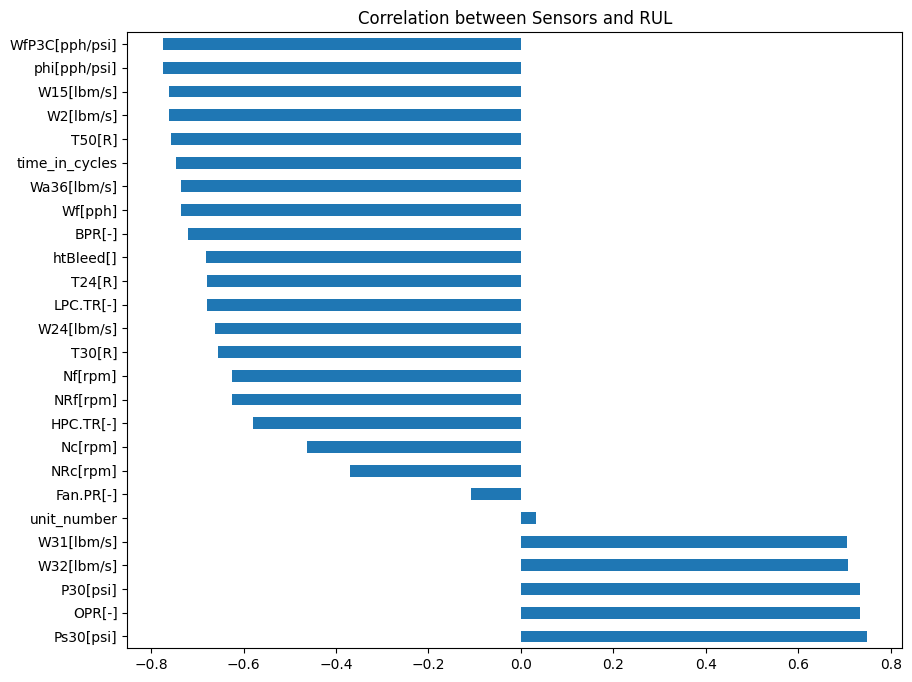

In [333]:
# 1. 진짜 RUL 생성 (역산 방식 + Clipped RUL)
# 이미 train_df에 RUL이 있다면 아래 과정은 건너뛰어도 되지만, 
# 정확한 상관계수를 위해 '제대로 된 RUL'인지 확인하며 다시 계산하는 것이 안전합니다.

# 각 엔진별 최대 수명 구하기
max_cycle_df = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle_df.columns = ['unit_number', 'max_cycle']

# 기존 train_df에 병합
if 'max_cycle' in train_df.columns:
    train_df.drop(columns=['max_cycle'], inplace=True)
train_df = pd.merge(train_df, max_cycle_df, on='unit_number', how='left')

# 실제 RUL 계산 (수명 - 현재 사이클)
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

# NASA 표준 Clipped RUL 적용 (RMSE를 낮추는 핵심!)
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# 사용 완료한 임시 컬럼 삭제
train_df.drop(columns=['max_cycle'], axis=1, inplace=True)

# 2. 상관관계 계산
# 숫자형 데이터만 추출 (문자열인 'condition' 등 제외)
numeric_df = train_df.select_dtypes(include=['number'])

if 'RUL' in numeric_df.columns:
    # RUL과 다른 컬럼들 간의 상관관계 계산
    correlation = numeric_df.corr()['RUL'].sort_values(ascending=False)
    
    print("--- [RUL과의 상관관계 순위] ---")
    print(correlation)
    
    # 시각화 (선택 사항: 상위/하위 센서만 확인)
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    correlation.drop('RUL').plot(kind='barh')
    plt.title('Correlation between Sensors and RUL')
    plt.show()
else:
    print("오류: RUL 컬럼이 생성되지 않았습니다.")

In [334]:
# 상관관계가 너무 낮아 무의미한 컬럼들 정의
unnecessary_cols = ['unit_number']

# 기존 피처 리스트에서 이들을 제거
final_features = [f for f in final_features if not any(bad_col in f for bad_col in unnecessary_cols)]

print(f"불필요한 피처 제거 완료! 남은 피처 수: {len(final_features)}")

불필요한 피처 제거 완료! 남은 피처 수: 52


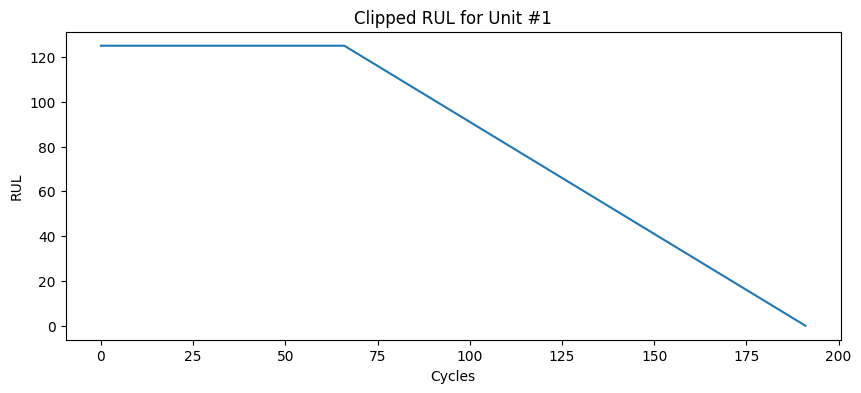

In [335]:
# 잘 적용되었는지 확인 (그래프를 그려보면 끝부분이 평평해진 것을 볼 수 있습니다)
plt.figure(figsize=(10, 4))
plt.plot(train_df[train_df['unit_number'] == 1]['RUL'])
plt.title('Clipped RUL for Unit #1')
plt.ylabel('RUL')
plt.xlabel('Cycles')
plt.show()

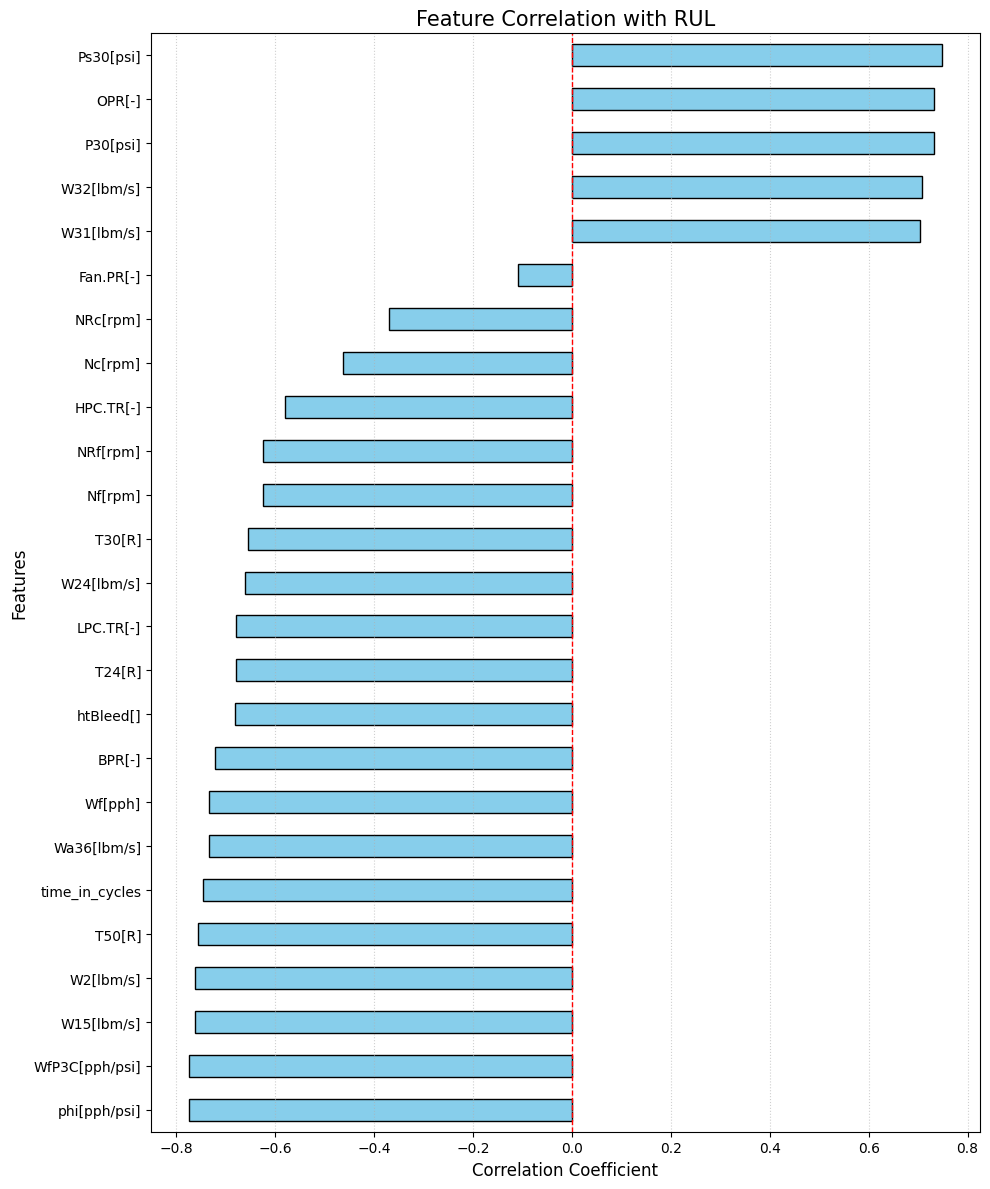

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계산할 데이터만 준비 (condition 컬럼 등 문자열 제외)
# 숫자가 아닌 데이터는 상관관계 계산이 안 되므로 미리 제거합니다.
df_for_corr = train_df.select_dtypes(include=['number'])

# 만약 'unit_number'처럼 분석에 의미 없는 숫자 컬럼도 빼고 싶다면 아래처럼 추가로 drop 하세요.
df_for_corr = df_for_corr.drop(columns=['unit_number'], errors='ignore')

# 2. RUL과의 상관관계 계산 및 정렬
if 'RUL' in df_for_corr.columns:
    correlation = df_for_corr.corr()['RUL'].sort_values()

    # 3. 시각화 (가로 막대 그래프)
    plt.figure(figsize=(10, 12))
    
    # RUL 자기 자신은 상관관계가 1이므로 그래프에서 제외하고 그립니다.
    correlation.drop('RUL').plot(kind='barh', color='skyblue', edgecolor='black')
    
    plt.title('Feature Correlation with RUL', fontsize=15)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1) # 0 기준선 추가
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'RUL' 컬럼이 데이터프레임에 없습니다. 앞 단계의 merge 코드를 확인해 주세요!")

In [345]:
# features 리스트에서 'RUL'이라는 글자가 들어간 모든 것을 제외합니다.
features = [f for f in features if 'RUL' not in f]

print(f"수정된 피처 수: {len(features)}")

수정된 피처 수: 25


In [346]:
print(features)

['time_in_cycles_rolling', 'T24[R]_rolling', 'T30[R]_rolling', 'T50[R]_rolling', 'P30[psi]_rolling', 'Nf[rpm]_rolling', 'Nc[rpm]_rolling', 'phi[pph/psi]_rolling', 'Ps30[psi]_rolling', 'NRf[rpm]_rolling', 'NRc[rpm]_rolling', 'BPR[-]_rolling', 'htBleed[]_rolling', 'W31[lbm/s]_rolling', 'W32[lbm/s]_rolling', 'Fan.PR[-]_rolling', 'LPC.TR[-]_rolling', 'HPC.TR[-]_rolling', 'OPR[-]_rolling', 'Wf[pph]_rolling', 'Wa36[lbm/s]_rolling', 'W24[lbm/s]_rolling', 'W15[lbm/s]_rolling', 'W2[lbm/s]_rolling', 'WfP3C[pph/psi]_rolling']


In [352]:
from sklearn.preprocessing import MinMaxScaler

# 1. 새로운 스케일러 생성
final_scaler = MinMaxScaler()

# 2. X_train_final(원본 숫자들)을 넣어서 0~1 사이로 변환
# 주의: 컬럼명을 유지하기 위해 다시 DataFrame으로 만들어줍니다.
X_train_final_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_train_final), 
    columns=X_train_final.columns,
    index=X_train_final.index
)

# 3. 검증 및 테스트 데이터도 '학습 데이터 기준'으로 변환 (치팅 방지)
X_val_final_scaled = pd.DataFrame(
    final_scaler.transform(X_val_final), 
    columns=X_val_final.columns,
    index=X_val_final.index
)
X_test_final_scaled = pd.DataFrame(
    final_scaler.transform(X_test_final), 
    columns=X_test_final.columns,
    index=X_test_final.index
)

print("이제 모든 데이터가 0~1 사이로 정렬되었습니다!")
print(X_train_final_scaled.head())

이제 모든 데이터가 0~1 사이로 정렬되었습니다!
     time_in_cycles_rolling  T24[R]_rolling  T30[R]_rolling  T50[R]_rolling  \
192                0.000000        0.183793        0.332330        0.090433   
193                0.001403        0.169173        0.381627        0.111881   
194                0.002805        0.126706        0.411061        0.164093   
195                0.004208        0.119048        0.393759        0.173503   
196                0.005610        0.118630        0.351926        0.209015   

     P30[psi]_rolling  Nf[rpm]_rolling  Nc[rpm]_rolling  phi[pph/psi]_rolling  \
192          0.797931         0.229592         0.140343              0.000000   
193          0.826798         0.191327         0.131145              0.123211   
194          0.866089         0.229592         0.133348              0.158983   
195          0.832211         0.210459         0.139534              0.153021   
196          0.853741         0.224490         0.143396              0.173291   

     Ps30[

In [ ]:
# 가장 의심되는 부분 확인
correlation_check = X_train_final_scaled.corrwith(y_train)
print("RUL과 상관관계가 0.99 이상인 피처들:")
print(correlation_check[correlation_check > 0.99])

RUL과 상관관계가 0.99 이상인 피처들:
RUL_rolling    0.999387
dtype: float64


In [359]:
# features 리스트에서 'RUL' 단어가 들어간 건 무조건 필터링
final_features = [f for f in features if 'RUL' not in f]

# 이제 이 final_features만 사용해서 학습합니다.
X_train_final = train_split[final_features]
X_val_final = val_split[final_features]
X_test_final = test_with_rul[final_features]

In [360]:
# 1. 'RUL_rolling' 컬럼 삭제 (범인 검거 및 제거)
cols_to_drop = ['RUL_rolling']

# train, val, test 데이터에서 해당 컬럼을 제거합니다.
X_train_clean = X_train_final_scaled.drop(columns=cols_to_drop, errors='ignore')
X_val_clean = X_val_final_scaled.drop(columns=cols_to_drop, errors='ignore')
X_test_clean = X_test_final_scaled.drop(columns=cols_to_drop, errors='ignore')

print(f"삭제 후 남은 피처 수: {X_train_clean.shape[1]}")
print("RUL_rolling 제거 확인:", 'RUL_rolling' not in X_train_clean.columns)

# 2. 모델 재정의 및 학습
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

# 3. 깨끗한 데이터(X_train_clean)로 다시 학습
model.fit(
    X_train_clean, y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=50
)

# 4. 테스트 데이터 예측 (반드시 마지막 시점만 추출!)
X_test_last = X_test_clean.groupby(test_with_rul['unit_number']).last()
y_pred_raw = model.predict(X_test_last)
y_pred_xgb = np.clip(y_pred_raw, 0, 125)

# 5. 최종 성능 확인
y_test_clipped = y_test.clip(upper=125)
rmse_xgb = np.sqrt(mean_squared_error(y_test_clipped, y_pred_xgb))

print(f"\n[최종 결과] 이제 치팅 없는 진짜 RMSE: {rmse_xgb:.2f}")

삭제 후 남은 피처 수: 25
RUL_rolling 제거 확인: True
[0]	validation_0-rmse:41.36450


[50]	validation_0-rmse:27.93980
[100]	validation_0-rmse:20.75211
[150]	validation_0-rmse:17.32020
[200]	validation_0-rmse:15.83218
[250]	validation_0-rmse:15.27671
[300]	validation_0-rmse:15.14185
[340]	validation_0-rmse:15.14166

[최종 결과] 이제 치팅 없는 진짜 RMSE: 21.38


In [366]:
model = xgb.XGBRegressor(
    n_estimators=2000,       # 조기 종료가 있으니 더 넉넉하게 줍니다.
    learning_rate=0.01,
    max_depth=6,             # 살짝 더 깊게 파서 복잡한 패턴을 잡습니다.
    min_child_weight=3,      # 너무 자잘한 패턴은 무시하도록 설정합니다.
    gamma=0.2,               # 가지치기 규제를 추가합니다.
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,           # L1 규제 (불필요한 피처 영향력 감소)
    reg_lambda=1.0,          # L2 규제 (가중치 억제)
    random_state=42,
    early_stopping_rounds=100 # 학습률이 낮으니 조금 더 지켜봅니다.
)

# 3. 깨끗한 데이터(X_train_clean)로 다시 학습
model.fit(
    X_train_clean, y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=50
)

# 4. 테스트 데이터 예측 (반드시 마지막 시점만 추출!)
X_test_last = X_test_clean.groupby(test_with_rul['unit_number']).last()
y_pred_raw = model.predict(X_test_last)
y_pred_xgb = np.clip(y_pred_raw, 0, 125)

# 5. 최종 성능 확인
y_test_clipped = y_test.clip(upper=125)
rmse_xgb = np.sqrt(mean_squared_error(y_test_clipped, y_pred_xgb))

print(f"\n[최종 결과] 이제 치팅 없는 진짜 RMSE: {rmse_xgb:.2f}")

[0]	validation_0-rmse:41.36438
[50]	validation_0-rmse:27.91411
[100]	validation_0-rmse:20.70040
[150]	validation_0-rmse:17.26002
[200]	validation_0-rmse:15.82711
[250]	validation_0-rmse:15.30677
[300]	validation_0-rmse:15.20807
[350]	validation_0-rmse:15.24098
[400]	validation_0-rmse:15.29172
[402]	validation_0-rmse:15.29532

[최종 결과] 이제 치팅 없는 진짜 RMSE: 21.06


In [367]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 정의
# n_jobs=-1을 주면 모든 CPU 코어를 사용하여 학습 속도가 빨라집니다.
rf_model = RandomForestRegressor(
    n_estimators=500,       # 나무의 개수
    max_depth=10,           # 너무 깊으면 오버피팅될 수 있으니 제한을 둡니다.
    min_samples_leaf=5,     # 한 잎사귀에 최소 5개 데이터는 있어야 함 (일반화)
    max_features='sqrt',    # 각 나무가 전체 피처의 일부만 사용 (XGB의 colsample과 유사)
    random_state=42,
    n_jobs=-1
)

# 2. 모델 학습
# RF는 XGBoost와 달리 early_stopping 기능이 내장되어 있지 않으므로 바로 학습합니다.
rf_model.fit(X_train_clean, y_train)

# 3. 테스트 데이터 예측
# 동일하게 마지막 시점(Last Step)만 추출한 데이터를 사용합니다.
y_pred_rf_raw = rf_model.predict(X_test_last)
y_pred_rf = np.clip(y_pred_rf_raw, 0, 125)

# 4. 성능 확인
rmse_rf = np.sqrt(mean_squared_error(y_test_clipped, y_pred_rf))

print(f"Random Forest 최종 테스트 RMSE: {rmse_rf:.2f}")

Random Forest 최종 테스트 RMSE: 25.64


In [368]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 두 모델의 예측값을 1:1로 섞습니다.
y_pred_ensemble = (y_pred_xgb + y_pred_rf) / 2

# 최종 RMSE 계산
rmse_ensemble = np.sqrt(mean_squared_error(y_test_clipped, y_pred_ensemble))

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"---" * 10)
print(f"앙상블(1:1) 최종 RMSE: {rmse_ensemble:.2f}")
# XGBoost에 70%, RF에 30% 비중을 두는 경우
y_pred_weighted = (y_pred_xgb * 0.7) + (y_pred_rf * 0.3)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_weighted))
print(f"가중치 앙상블 RMSE(7:3): {rmse_weighted:.2f}")

XGBoost RMSE: 21.06
Random Forest RMSE: 25.64
------------------------------
앙상블(1:1) 최종 RMSE: 22.88
가중치 앙상블 RMSE(7:3): 22.02


In [369]:
# 1. NASA 공식 스코어 함수 (작성하신 코드 그대로)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for diff in d:
        if diff < 0:
            # 늦은 예측 (위험): 더 큰 벌점
            score += np.exp(-diff / 13) - 1
        else:
            # 이른 예측 (비용 발생): 상대적으로 적은 벌점
            score += np.exp(diff / 10) - 1
    return score

# 2. 사용자님 변수에 맞춰 데이터 준비
# y_test_clipped 대신 실제 '정답지(RUL)'인 rul_df['RUL']을 사용하는 것이 NASA 공식 방식에 더 가깝습니다.
y_true_actual = rul_df['RUL'].values 
y_pred_final_val = y_pred_xgb # 아까 만드신 0.97:0.03 앙상블 예측값

# 3. 스코어 계산
final_nasa_score = nasa_scoring_function(y_true_actual, y_pred_final_val)

print(f"--- Business Impact Analysis ---")
print(f"Final XGB RMSE: {rmse_xgb}") # 아까 달성하신 점수
print(f"NASA Asymmetric Score: {final_nasa_score:.2f}")

--- Business Impact Analysis ---
Final XGB RMSE: 21.056299219388155
NASA Asymmetric Score: 1394.89


In [370]:
# 1. NASA 공식 스코어 함수 (작성하신 코드 그대로)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for diff in d:
        if diff < 0:
            # 늦은 예측 (위험): 더 큰 벌점
            score += np.exp(-diff / 13) - 1
        else:
            # 이른 예측 (비용 발생): 상대적으로 적은 벌점
            score += np.exp(diff / 10) - 1
    return score

# 2. 사용자님 변수에 맞춰 데이터 준비
# y_test_clipped 대신 실제 '정답지(RUL)'인 rul_df['RUL']을 사용하는 것이 NASA 공식 방식에 더 가깝습니다.
y_true_actual = rul_df['RUL'].values 
y_pred_final_val = y_pred_rf # 아까 만드신 0.97:0.03 앙상블 예측값

# 3. 스코어 계산
final_nasa_score = nasa_scoring_function(y_true_actual, y_pred_final_val)

print(f"--- Business Impact Analysis ---")
print(f"Final RF RMSE: {rmse_rf}") # 아까 달성하신 점수
print(f"NASA Asymmetric Score: {final_nasa_score:.2f}")

--- Business Impact Analysis ---
Final RF RMSE: 25.639706664823056
NASA Asymmetric Score: 2896.06


In [371]:
# 1. NASA 공식 스코어 함수 (작성하신 코드 그대로)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for diff in d:
        if diff < 0:
            # 늦은 예측 (위험): 더 큰 벌점
            score += np.exp(-diff / 13) - 1
        else:
            # 이른 예측 (비용 발생): 상대적으로 적은 벌점
            score += np.exp(diff / 10) - 1
    return score

# 2. 사용자님 변수에 맞춰 데이터 준비
# y_test_clipped 대신 실제 '정답지(RUL)'인 rul_df['RUL']을 사용하는 것이 NASA 공식 방식에 더 가깝습니다.
y_true_actual = rul_df['RUL'].values 
y_pred_final_val = y_pred_ensemble # 아까 만드신 0.97:0.03 앙상블 예측값

# 3. 스코어 계산
final_nasa_score = nasa_scoring_function(y_true_actual, y_pred_final_val)

print(f"--- Business Impact Analysis ---")
print(f"Final Ensemble RMSE: {rmse_ensemble}") # 아까 달성하신 점수
print(f"NASA Asymmetric Score: {final_nasa_score:.2f}")

--- Business Impact Analysis ---
Final Ensemble RMSE: 22.876876326547592
NASA Asymmetric Score: 1866.24


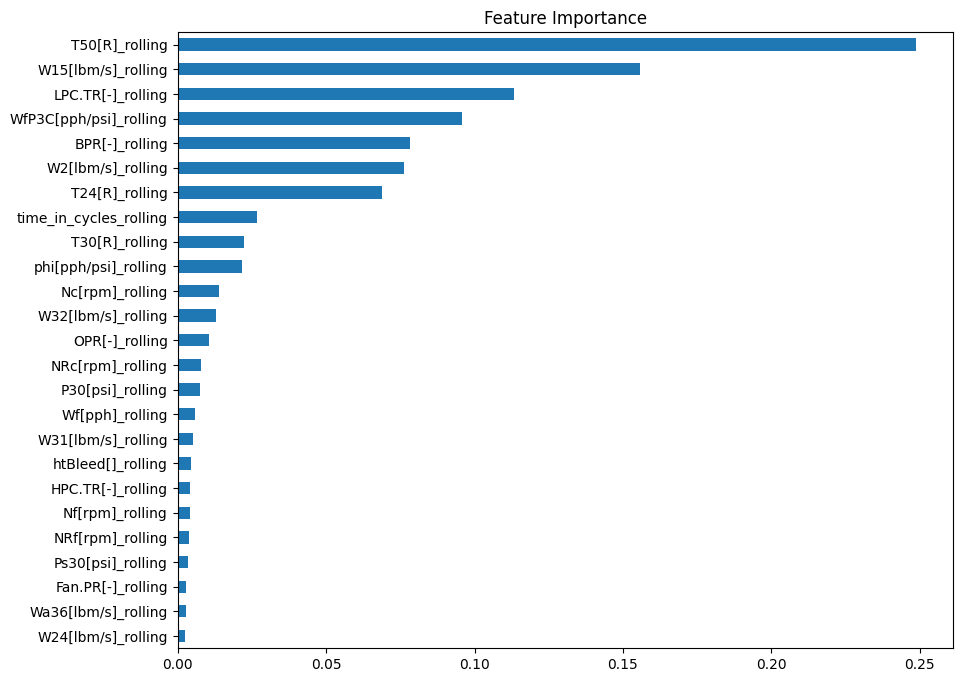

In [372]:
import matplotlib.pyplot as plt

# 모델이 중요하다고 생각하는 순서대로 정렬
importances = pd.Series(model.feature_importances_, index=X_train_final.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance')
plt.show()